1. **Probability and Expected Value**

   - Generate 10,000 random samples of flipping 3 coins (use `np.random.binomial()`)
   - Plot the probability distribution of getting 0, 1, 2, or 3 heads
   - Calculate the expected value (mean) of your distribution
   - Compare your empirical results with the theoretical probability for each outcome

Expected distribution mean: 1.5011
empirical prob: [0.1249 0.3775 0.3692 0.1284] 
theoretical prob: [0.125, 0.375, 0.375, 0.125]


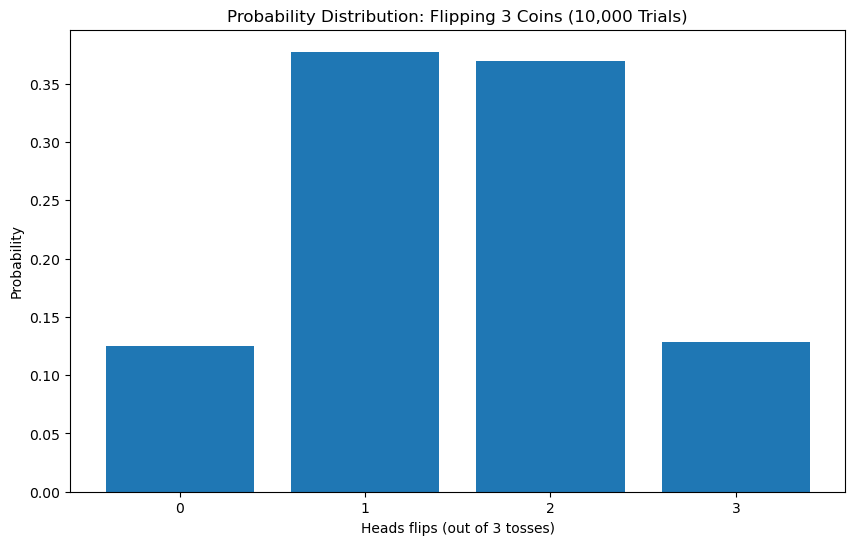

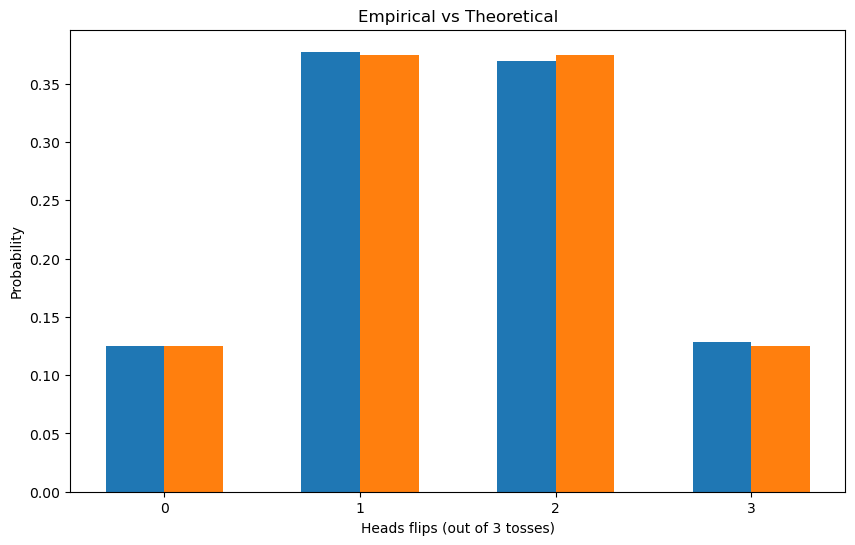

In [23]:
from math import factorial

# Calculate "n_choose_k" - the number of ways to arrange k heads in n flips
# Divide by total possible outcomes (2^n) to get probability
def coinflip_prob(n, k):    
    n_choose_k = factorial(n)/(factorial(k)*factorial(n-k))  
    return n_choose_k/2**n

import numpy as np
import matplotlib.pyplot as plt

n_experiments = 10_000
heads_count = np.random.binomial(3, 0.5, n_experiments)
heads, event_count = np.unique(heads_count, return_counts=True)
empirical_prob = event_count/n_experiments

plt.figure(figsize=(10, 6))
plt.title('Probability Distribution: Flipping 3 Coins (10,000 Trials)')
plt.bar(heads, empirical_prob)
plt.ylabel('Probability')
plt.xticks(heads)
_ = plt.xlabel('Heads flips (out of 3 tosses)')

mean = np.mean(heads_count)
print(f"Expected distribution mean:", mean)

theoretical_prob = [coinflip_prob(3, x) for x in range(4)]
print(f"empirical prob:", empirical_prob, "\ntheoretical prob:", theoretical_prob)

plt.figure(figsize=(10, 6))
plt.title('Empirical vs Theoretical')
plt.bar(heads -0.15, empirical_prob, label="Empirical", width=0.3)
plt.bar(heads +0.15, theoretical_prob, label="Theoretical", width=0.3)
plt.ylabel('Probability')
plt.xticks(heads)
_ = plt.xlabel('Heads flips (out of 3 tosses)')



2. **Normal Distribution and Statistical Testing**

   - Generate two samples from normal distributions:
     - Sample A: 100 values with mean=70, std=5
     - Sample B: 100 values with mean=73, std=5
   - Create a box plot comparing the two distributions
   - Conduct an independent t-test to determine if the means are significantly different
   - Calculate and visualize the 95% confidence intervals for both samples

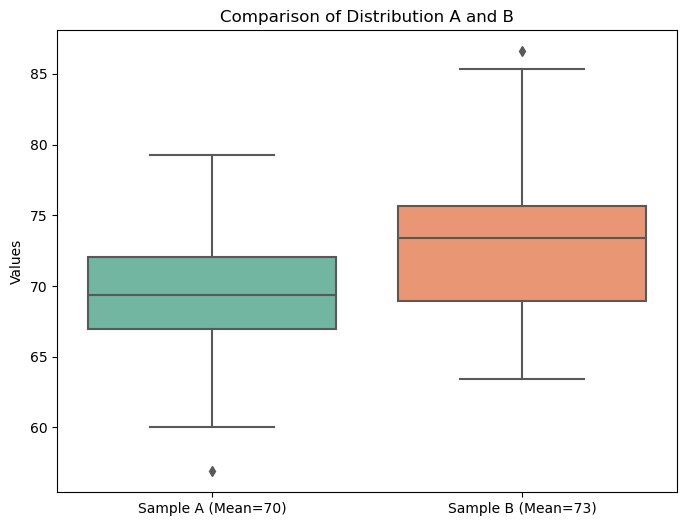

T-statistic: -5.5140
P-value: 1.089e-07
Decision: Reject Null Hypothesis (H0). The means are significantly different.


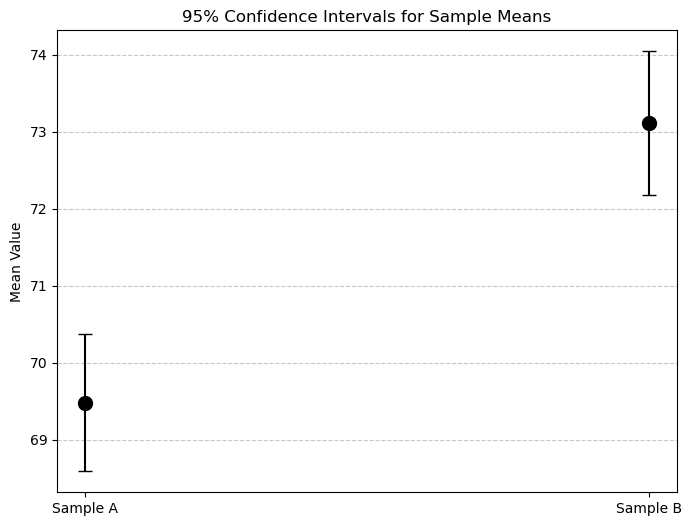


Sample A 95% CI: [68.59, 70.37]
Sample B 95% CI: [72.18, 74.05]


In [47]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate two samples from normal distributions
np.random.seed(42)
sample_a = np.random.normal(70, 5, 100)
sample_b = np.random.normal(73, 5, 100)

# 2. Create a box plot comparing the two distributions
plt.figure(figsize=(8, 6))
sns.boxplot(data=[sample_a, sample_b], palette="Set2")
plt.xticks(np.arange(2), ['Sample A (Mean=70)', 'Sample B (Mean=73)'])
plt.title('Comparison of Distribution A and B')
plt.ylabel('Values')
plt.show()

# 3. Conduct an independent t-test
t_stat, p_value = st.ttest_ind(sample_a, sample_b, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4g}")

# Decision making based on the significance level (alpha = 0.05) [2]
if p_value < 0.05:
    print("Decision: Reject Null Hypothesis (H0). The means are significantly different.")
else:
    print("Decision: Fail to Reject H0. The difference could be due to chance.")

# 4. Calculate and visualize 95% Confidence Intervals
def get_ci(data):
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return mean, 1.96 * se # 1.96 is the Z-score for 95% confidence [History]

mean_a, error_a = get_ci(sample_a)
mean_b, error_b = get_ci(sample_b)

# Visualizing the CIs using a point plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(['Sample A', 'Sample B'], [mean_a, mean_b], yerr=[error_a, error_b], 
             fmt='o', color='black', capsize=5, markersize=10)
plt.title('95% Confidence Intervals for Sample Means')
plt.ylabel('Mean Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nSample A 95% CI: [{mean_a - error_a:.2f}, {mean_a + error_a:.2f}]")
print(f"Sample B 95% CI: [{mean_b - error_b:.2f}, {mean_b + error_b:.2f}]")

3. **Correlation Analysis**
   - Using the iris dataset (from seaborn), analyze the relationship between:
     - Sepal length and petal length
     - Sepal width and petal width
   - For each pair:
     - Create a scatter plot
     - Calculate the Pearson correlation coefficient and p-value
     - Calculate and interpret the R-squared value
   - Which pair shows a stronger relationship? Explain why.

/home/khoonseng/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/khoonseng/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


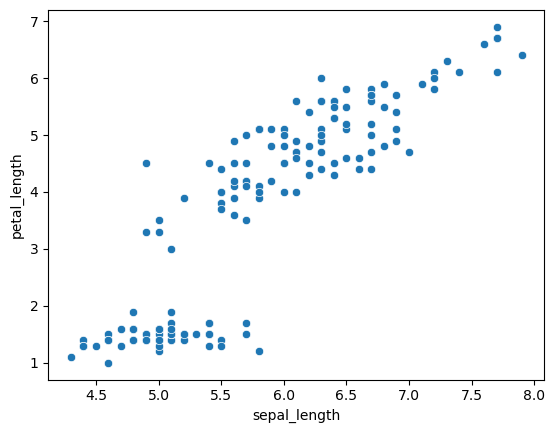

/home/khoonseng/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/khoonseng/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


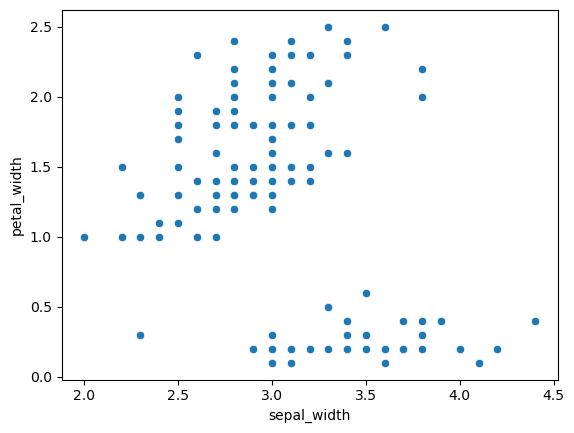

Sepal/Petal Length - Pearson correlation coefficient (r): 0.8717537758865831
Sepal/Petal Length - Pearson p-value: 1.0386674194498827e-47
Sepal/Petal Width - Pearson correlation coefficient (r): -0.36612593253643905
Sepal/Petal Width - Pearson p-value: 4.0732285132462e-06
Sepal/Petal Length - R² (coefficient of determination): 0.7599546457725149
Sepal/Petal Width - R² (coefficient of determination): 0.13404819847567712


In [53]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset('iris')

# Extract two variables to examine their relationship
sns.scatterplot(x=iris.sepal_length, y=iris.petal_length)
plt.show()

sns.scatterplot(x=iris.sepal_width, y=iris.petal_width)
plt.show()

# Calculate Pearson correlation coefficient (r) and p-value
# r ranges from -1 to +1:
#   +1 = perfect positive correlation
#    0 = no linear correlation
#   -1 = perfect negative correlation
# p-value tests statistical significance (discussed in Stats section)

r_sepal_petal_length = st.pearsonr(iris.sepal_length, iris.petal_length)[0]
p_sepal_petal_length = st.pearsonr(iris.sepal_length, iris.petal_length)[1]
print(f"Sepal/Petal Length - Pearson correlation coefficient (r):", r_sepal_petal_length)
print(f"Sepal/Petal Length - Pearson p-value:", p_sepal_petal_length)

r_sepal_petal_width = st.pearsonr(iris.sepal_width, iris.petal_width)[0]
p_sepal_petal_width = st.pearsonr(iris.sepal_width, iris.petal_width)[1]
print(f"Sepal/Petal Width - Pearson correlation coefficient (r):", r_sepal_petal_width)
print(f"Sepal/Petal Width - Pearson p-value:", p_sepal_petal_width)

# Calculate R² (coefficient of determination) by squaring the correlation
# R² ranges from 0 to 1 and represents "proportion of variance explained"
# Example: R²=0.25 means 25% of variation in one variable explained by the other
# Commonly used in regression analysis to assess model fit

r_sq_length = st.pearsonr(iris.sepal_length, iris.petal_length)[0]**2
r_sq_width = st.pearsonr(iris.sepal_width, iris.petal_width)[0]**2
print(f"Sepal/Petal Length - R² (coefficient of determination):", r_sq_length)
print(f"Sepal/Petal Width - R² (coefficient of determination):", r_sq_width)


## Analysis and Comparison
Based on the statistical principles in the sources and our conversation history, here is how to interpret the results:
1. Sepal Length vs. Petal Length:
- Interpretation: This pair typically shows a very strong positive correlation (r≈0.87).
- R-squared: With an R² of approximately 0.76, about 76% of the variation in petal length can be predicted just by knowing the sepal length. This is a powerful "informed decision" based on the data.
2. Sepal Width vs. Petal Width:
- Interpretation: This pair typically shows a weak negative correlation (r≈−0.36).
- R-squared: With an R² of approximately 0.13, only about 13% of the variation is explained. Most of the relationship here is "noise" rather than a clear "signal".

Which pair shows a stronger relationship? 
The relationship between Sepal Length and Petal Length is significantly stronger.
Why?
- Correlation Coefficient (r): Its r value is much closer to +1, indicating a much tighter linear relationship than the other pair.
- Statistical Significance: While both typically have p<0.05 (meaning they are unlikely to be a "fluke"), the magnitude of the effect is far greater in the first pair.
- Predictive Power (R²): The first pair explains roughly 6 times more variance (76% vs 13%) than the second, making it a much more reliable clue for a "detective" trying to understand the biology of these flowers.